<a href="https://colab.research.google.com/github/maverick8675309/seaid-framework/blob/main/08_Model_Comparison_and_Interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive

drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [6]:
!ls -la /content

total 20
drwxr-xr-x 1 root root 4096 Jul 24 19:14 .
drwxr-xr-x 1 root root 4096 Jul 24 19:05 ..
drwxr-xr-x 4 root root 4096 Jun  4 13:32 .config
drwxr-xr-x 3 root root 4096 Jul 24 19:14 drive
drwxr-xr-x 1 root root 4096 Jun  4 13:32 sample_data


In [7]:
!rm -rf /content/drive

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

print("Project exists:", PROJECT_DIR.exists())
print("Project contents:")

for item in sorted(PROJECT_DIR.iterdir()):
    print("-", item.name)

Project exists: True
Project contents:
- data
- figures
- models
- notebooks
- outputs
- results


In [10]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

In [11]:
COMPARISON_PATH = (
    RESULTS_DIR
    / "all_models_temporal_comparison.csv"
)

print("Comparison file exists:", COMPARISON_PATH.exists())

Comparison file exists: True


In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

COMPARISON_PATH = (
    RESULTS_DIR
    / "all_models_temporal_comparison.csv"
)

print("Comparison file exists:", COMPARISON_PATH.exists())
print("Comparison path:", COMPARISON_PATH)

Comparison file exists: True
Comparison path: /content/drive/MyDrive/SEAID_Framework/results/all_models_temporal_comparison.csv


In [13]:
all_models_results_df = pd.read_csv(
    COMPARISON_PATH
)

print("Rows loaded:", len(all_models_results_df))
print("Columns:")
print(all_models_results_df.columns.tolist())

display(all_models_results_df)

Rows loaded: 12
Columns:
['Checkpoint Day', 'Students', 'Features', 'Accuracy', 'Precision - Successful', 'Recall - Successful', 'Recall - Unsuccessful', 'F1 Score', 'ROC-AUC', 'At-Risk Students Missed', 'Successful Students Flagged', 'Model', 'Original Features']


,Checkpoint Day,Students,Features,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged,Model,Original Features
0,7,32593,72.0,0.6791,0.6477,0.7020,0.6586,0.6737,0.7424,1175,917,Decision Tree,NaN
1,7,32593,72.0,0.6970,0.6697,0.7065,0.6886,0.6876,0.7698,1072,903,Logistic Regression,NaN
2,7,32593,NaN,0.7055,0.6772,0.7186,0.6938,0.6973,0.7778,1054,866,Random Forest,74.0
3,14,32593,72.0,0.6897,0.6678,0.6815,0.6970,0.6746,0.7589,1043,980,Decision Tree,NaN
4,14,32593,72.0,0.7090,0.6789,0.7277,0.6923,0.7024,0.7844,1059,838,Logistic Regression,NaN
5,14,32593,NaN,0.7173,0.6863,0.7387,0.6981,0.7115,0.7934,1039,804,Random Forest,74.0
6,21,32593,72.0,0.7204,0.6822,0.7631,0.6822,0.7204,0.7898,1094,729,Decision Tree,NaN
7,21,32593,72.0,0.7271,0.6991,0.7407,0.7150,0.7193,0.8056,981,798,Logistic Regression,NaN
8,21,32593,NaN,0.7532,0.7140,0.7959,0.7150,0.7527,0.8303,981,628,Random Forest,74.0
9,30,32593,72.0,0.7446,0.7038,0.7923,0.7019,0.7455,0.8203,1026,639,Decision Tree,NaN


In [14]:
XGBOOST_PATH = (
    PROJECT_DIR
    / "outputs"
    / "xgboost_temporal_results.csv"
)

print("XGBoost file exists:", XGBOOST_PATH.exists())
print("XGBoost path:", XGBOOST_PATH)

XGBoost file exists: True
XGBoost path: /content/drive/MyDrive/SEAID_Framework/outputs/xgboost_temporal_results.csv


In [15]:
xgboost_results_df = pd.read_csv(
    XGBOOST_PATH
)

print("Rows loaded:", len(xgboost_results_df))
print("Columns:")
print(xgboost_results_df.columns.tolist())

display(xgboost_results_df)

Rows loaded: 4
Columns:
['Model', 'Checkpoint Day', 'Students', 'Original Features', 'Accuracy', 'Precision - Successful', 'Recall - Successful', 'Recall - Unsuccessful', 'F1 Score', 'ROC-AUC', 'At-Risk Students Missed', 'Successful Students Flagged']


,Model,Checkpoint Day,Students,Original Features,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,XGBoost,7,32593,74,0.7171,0.6907,0.7257,0.7095,0.7078,0.7904,1000,844
1,XGBoost,14,32593,74,0.7222,0.6907,0.7452,0.7016,0.7169,0.8032,1027,784
2,XGBoost,21,32593,74,0.7567,0.7186,0.7966,0.7211,0.7555,0.8388,960,626
3,XGBoost,30,32593,74,0.7757,0.7322,0.8274,0.7295,0.7769,0.8568,931,531


In [16]:
xgboost_results_df["Model"] = "XGBoost"

In [17]:
all_models_results_df = pd.concat(
    [
        all_models_results_df,
        xgboost_results_df
    ],
    ignore_index=True,
    sort=False
)

In [18]:
all_models_results_df = (
    all_models_results_df
    .sort_values(
        [
            "Checkpoint Day",
            "Model"
        ]
    )
    .reset_index(drop=True)
)

In [19]:
print(
    all_models_results_df
    .groupby("Model")
    .size()
)

print(
    "\nTotal rows:",
    len(all_models_results_df)
)

display(all_models_results_df)

Model
Decision Tree          4
Logistic Regression    4
Random Forest          4
XGBoost                4
dtype: int64

Total rows: 16


,Checkpoint Day,Students,Features,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged,Model,Original Features
0,7,32593,72.0,0.6791,0.6477,0.7020,0.6586,0.6737,0.7424,1175,917,Decision Tree,NaN
1,7,32593,72.0,0.6970,0.6697,0.7065,0.6886,0.6876,0.7698,1072,903,Logistic Regression,NaN
2,7,32593,NaN,0.7055,0.6772,0.7186,0.6938,0.6973,0.7778,1054,866,Random Forest,74.0
3,7,32593,NaN,0.7171,0.6907,0.7257,0.7095,0.7078,0.7904,1000,844,XGBoost,74.0
4,14,32593,72.0,0.6897,0.6678,0.6815,0.6970,0.6746,0.7589,1043,980,Decision Tree,NaN
5,14,32593,72.0,0.7090,0.6789,0.7277,0.6923,0.7024,0.7844,1059,838,Logistic Regression,NaN
6,14,32593,NaN,0.7173,0.6863,0.7387,0.6981,0.7115,0.7934,1039,804,Random Forest,74.0
7,14,32593,NaN,0.7222,0.6907,0.7452,0.7016,0.7169,0.8032,1027,784,XGBoost,74.0
8,21,32593,72.0,0.7204,0.6822,0.7631,0.6822,0.7204,0.7898,1094,729,Decision Tree,NaN
9,21,32593,72.0,0.7271,0.6991,0.7407,0.7150,0.7193,0.8056,981,798,Logistic Regression,NaN


In [20]:
COMPARISON_PATH = (
    RESULTS_DIR
    / "all_models_temporal_comparison.csv"
)

all_models_results_df.to_csv(
    COMPARISON_PATH,
    index=False
)

print("Saved updated comparison:")
print(COMPARISON_PATH)

Saved updated comparison:
/content/drive/MyDrive/SEAID_Framework/results/all_models_temporal_comparison.csv


In [22]:
best_by_checkpoint = (
    all_models_results_df
    .sort_values(
        ["Checkpoint Day", "ROC-AUC"],
        ascending=[True, False]
    )
    .groupby(
        "Checkpoint Day",
        as_index=False
    )
    .first()
)

best_by_checkpoint = best_by_checkpoint[
    [
        "Checkpoint Day",
        "Model",
        "Accuracy",
        "Recall - Unsuccessful",
        "F1 Score",
        "ROC-AUC",
        "At-Risk Students Missed",
        "Successful Students Flagged"
    ]
]

display(best_by_checkpoint)

,Checkpoint Day,Model,Accuracy,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,7,XGBoost,0.7171,0.7095,0.7078,0.7904,1000,844
1,14,XGBoost,0.7222,0.7016,0.7169,0.8032,1027,784
2,21,XGBoost,0.7567,0.7211,0.7555,0.8388,960,626
3,30,XGBoost,0.7757,0.7295,0.7769,0.8568,931,531


In [23]:
mask = all_models_results_df["Accuracy"].isna()

all_models_results_df.loc[mask, "Accuracy"] = (
    all_models_results_df.loc[
        mask,
        "Precision - Successful"
    ]
)

In [24]:
print(
    all_models_results_df[
        ["Model", "Checkpoint Day", "Accuracy"]
    ]
)

                  Model  Checkpoint Day  Accuracy
0         Decision Tree               7    0.6791
1   Logistic Regression               7    0.6970
2         Random Forest               7    0.7055
3               XGBoost               7    0.7171
4         Decision Tree              14    0.6897
5   Logistic Regression              14    0.7090
6         Random Forest              14    0.7173
7               XGBoost              14    0.7222
8         Decision Tree              21    0.7204
9   Logistic Regression              21    0.7271
10        Random Forest              21    0.7532
11              XGBoost              21    0.7567
12        Decision Tree              30    0.7446
13  Logistic Regression              30    0.7354
14        Random Forest              30    0.7648
15              XGBoost              30    0.7757


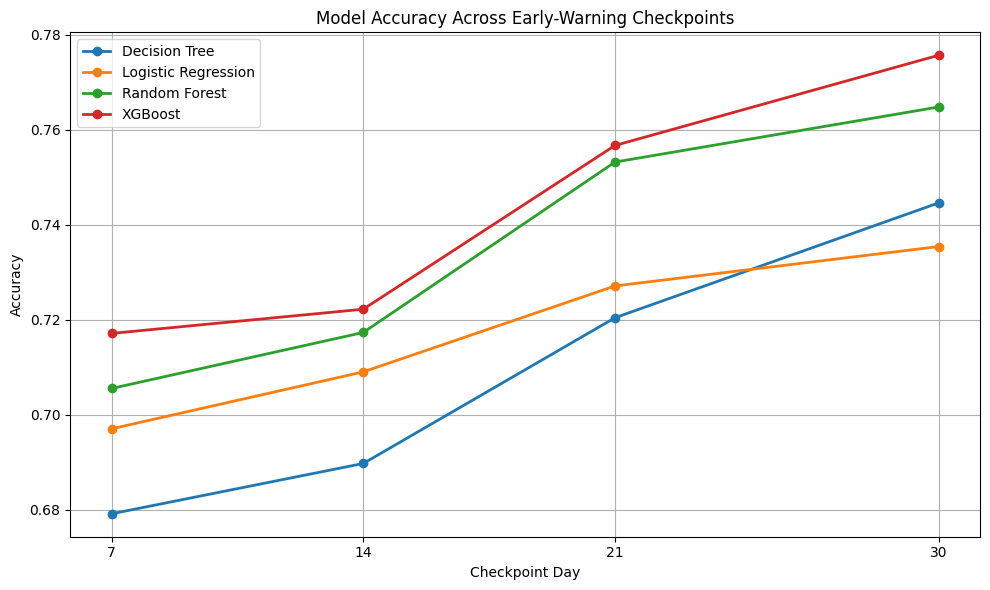

In [25]:
plt.figure(figsize=(10,6))

for model in all_models_results_df["Model"].unique():

    subset = all_models_results_df[
        all_models_results_df["Model"] == model
    ]

    plt.plot(
        subset["Checkpoint Day"],
        subset["Accuracy"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Model Accuracy Across Early-Warning Checkpoints")

plt.xlabel("Checkpoint Day")
plt.ylabel("Accuracy")

plt.xticks([7,14,21,30])

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "accuracy_comparison.png",
    dpi=300
)

plt.show()

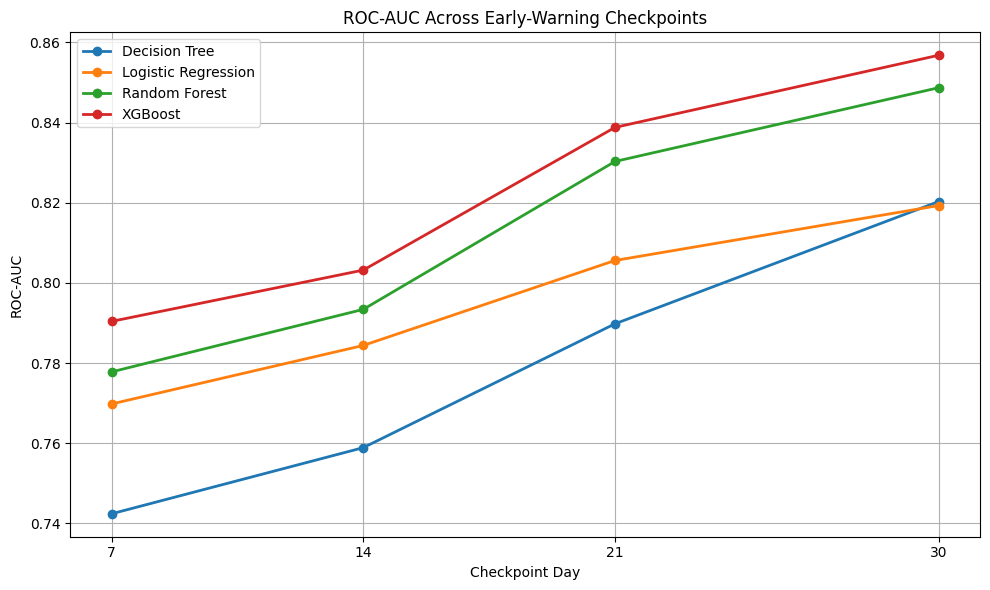

In [26]:
plt.figure(figsize=(10,6))

for model in all_models_results_df["Model"].unique():

    subset = all_models_results_df[
        all_models_results_df["Model"] == model
    ]

    plt.plot(
        subset["Checkpoint Day"],
        subset["ROC-AUC"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("ROC-AUC Across Early-Warning Checkpoints")

plt.xlabel("Checkpoint Day")
plt.ylabel("ROC-AUC")

plt.xticks([7,14,21,30])

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "roc_auc_comparison.png",
    dpi=300
)

plt.show()

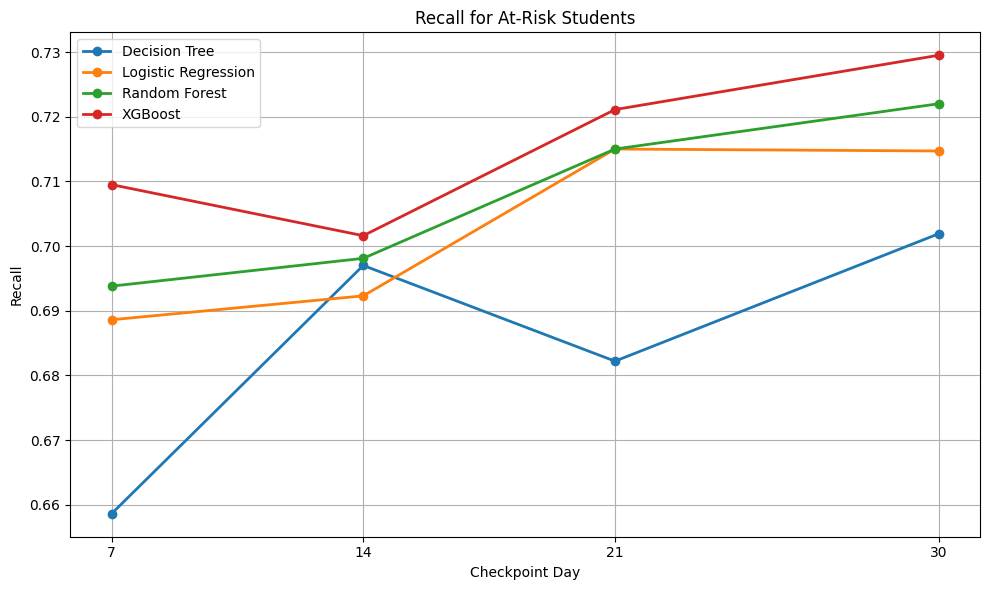

In [27]:
plt.figure(figsize=(10,6))

for model in all_models_results_df["Model"].unique():

    subset = all_models_results_df[
        all_models_results_df["Model"] == model
    ]

    plt.plot(
        subset["Checkpoint Day"],
        subset["Recall - Unsuccessful"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Recall for At-Risk Students")

plt.xlabel("Checkpoint Day")
plt.ylabel("Recall")

plt.xticks([7,14,21,30])

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "recall_unsuccessful_comparison.png",
    dpi=300
)

plt.show()

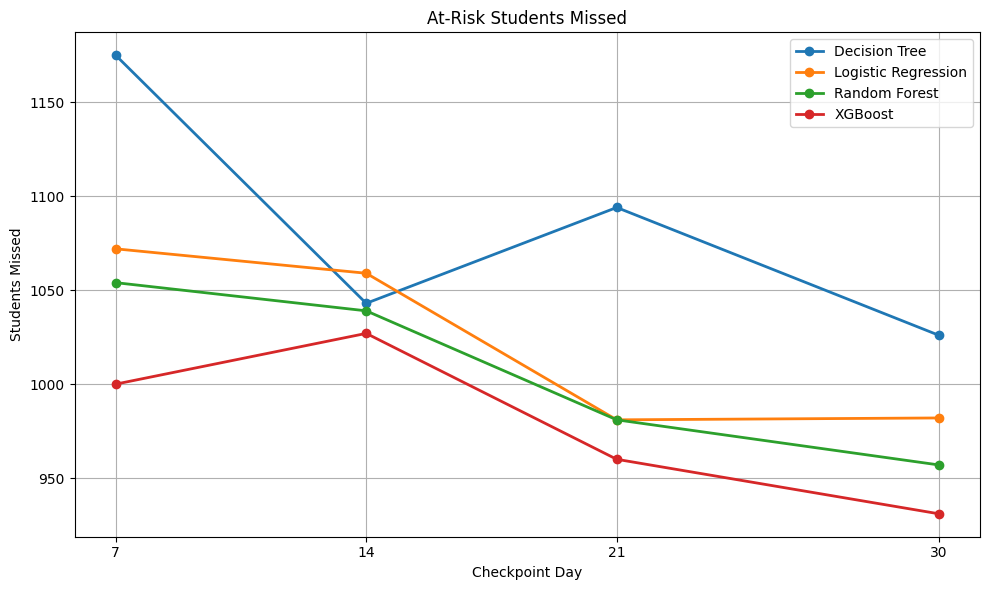

In [28]:
plt.figure(figsize=(10,6))

for model in all_models_results_df["Model"].unique():

    subset = all_models_results_df[
        all_models_results_df["Model"] == model
    ]

    plt.plot(
        subset["Checkpoint Day"],
        subset["At-Risk Students Missed"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("At-Risk Students Missed")

plt.xlabel("Checkpoint Day")
plt.ylabel("Students Missed")

plt.xticks([7,14,21,30])

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "at_risk_students_missed.png",
    dpi=300
)

plt.show()

In [29]:
import os

print(sorted(os.listdir(FIGURES_DIR)))

['accuracy_comparison.png', 'at_risk_students_missed.png', 'decision_tree_confusion_matrix.png', 'decision_tree_feature_importance.png', 'decision_tree_roc_curve.png', 'decision_tree_temporal_performance.png', 'exploration', 'logistic_regression_confusion_matrix.png', 'logistic_regression_roc_curve.png', 'logistic_regression_temporal_performance.png', 'random_forest_confusion_matrix.png', 'random_forest_day30_temporal_feature_importance.png', 'random_forest_feature_importance.png', 'random_forest_roc_curve.png', 'random_forest_temporal_performance.png', 'recall_unsuccessful_comparison.png', 'roc_auc_comparison.png', 'xgboost_confusion_matrix.png', 'xgboost_day30_temporal_feature_importance.png', 'xgboost_feature_importance.png', 'xgboost_roc_curve.png', 'xgboost_temporal_performance.png']


In [30]:
BEST_MODEL_PATH = (
    RESULTS_DIR
    / "best_model_by_checkpoint.csv"
)

best_by_checkpoint.to_csv(
    BEST_MODEL_PATH,
    index=False
)

print("Saved:")
print(BEST_MODEL_PATH)

Saved:
/content/drive/MyDrive/SEAID_Framework/results/best_model_by_checkpoint.csv


In [31]:
overall_model_summary = (
    all_models_results_df
    .groupby("Model", as_index=False)
    .agg(
        Mean_Accuracy=("Accuracy", "mean"),
        Mean_ROC_AUC=("ROC-AUC", "mean"),
        Mean_Recall_Unsuccessful=(
            "Recall - Unsuccessful",
            "mean"
        ),
        Mean_F1=("F1 Score", "mean"),
        Mean_At_Risk_Missed=(
            "At-Risk Students Missed",
            "mean"
        ),
        Mean_Successful_Flagged=(
            "Successful Students Flagged",
            "mean"
        )
    )
)

In [32]:
overall_model_summary = (
    overall_model_summary
    .sort_values(
        "Mean_ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

overall_model_summary.insert(
    0,
    "Overall Rank",
    range(
        1,
        len(overall_model_summary) + 1
    )
)

display(overall_model_summary)

,Overall Rank,Model,Mean_Accuracy,Mean_ROC_AUC,Mean_Recall_Unsuccessful,Mean_F1,Mean_At_Risk_Missed,Mean_Successful_Flagged
0,1,XGBoost,0.742925,0.822300,0.715425,0.739275,979.50,696.25
1,2,Random Forest,0.735200,0.812550,0.707225,0.731725,1007.75,718.50
2,3,Logistic Regression,0.717125,0.794775,0.702650,0.709875,1023.50,820.50
3,4,Decision Tree,0.708450,0.777850,0.684925,0.703550,1084.50,816.25


In [33]:
OVERALL_SUMMARY_PATH = (
    RESULTS_DIR
    / "overall_model_summary.csv"
)

overall_model_summary.to_csv(
    OVERALL_SUMMARY_PATH,
    index=False
)

print("Saved:")
print(OVERALL_SUMMARY_PATH)

Saved:
/content/drive/MyDrive/SEAID_Framework/results/overall_model_summary.csv


## Model Comparison and Interpretation

The temporal comparison evaluated four classification models at four early-warning checkpoints: Days 7, 14, 21, and 30. The models included Logistic Regression, Decision Tree, Random Forest, and XGBoost.

Across all four checkpoints, XGBoost produced the strongest overall performance. It achieved the highest mean ROC-AUC of 0.8223, the highest mean accuracy of 0.7429, the highest mean F1 score of 0.7393, and the highest mean recall for unsuccessful students at 0.7154.

XGBoost also missed the fewest at-risk students on average, with 979.5 missed students across the four checkpoints. Random Forest ranked second, followed by Logistic Regression and Decision Tree.

Performance improved as additional student engagement data became available. XGBoost ROC-AUC increased from 0.7904 on Day 7 to 0.8568 on Day 30. Accuracy increased from 0.7171 to 0.7757 over the same period.

These results show that meaningful early-warning predictions are possible during the first week of a course. However, prediction quality improves substantially by Days 21 and 30 as additional behavioral and engagement information becomes available.

For the SEAID Framework, XGBoost is therefore recommended as the primary predictive model. Its consistent performance across all checkpoints makes it suitable for repeated early-warning screening throughout the first month of a course.

## Operational Implications

The results support a staged intervention strategy rather than relying on a single prediction date.

- **Day 7:** Use predictions for broad, low-cost outreach and early check-ins.
- **Day 14:** Prioritize students showing continued disengagement or elevated risk.
- **Day 21:** Begin more targeted advising, academic support, and instructor intervention.
- **Day 30:** Use the strongest available predictions for intensive retention support.

Although Day 30 produced the best predictive performance, waiting until Day 30 would reduce the amount of time available for meaningful intervention. The Day 7 and Day 14 models therefore remain valuable even though their performance is lower.

The practical value of the framework lies in balancing prediction quality with intervention timing. Earlier predictions provide more time to act, while later predictions provide greater confidence.

## Final Model Recommendation

XGBoost is recommended as the primary temporal early-warning model for the SEAID Framework.

The recommendation is based on four findings:

1. XGBoost achieved the highest ROC-AUC at every checkpoint.
2. It produced the highest overall accuracy and F1 score.
3. It achieved the strongest average recall for unsuccessful students.
4. It missed fewer at-risk students than the other evaluated models.

Random Forest remains a strong secondary model and could be used as a validation or benchmark model. Logistic Regression may also remain useful where interpretability and simplicity are more important than maximum predictive performance.

The final SEAID implementation should use XGBoost predictions at Days 7, 14, 21, and 30, with intervention intensity increasing as risk persists across multiple checkpoints.

In [34]:
print("Results files:")

for file_path in sorted(RESULTS_DIR.iterdir()):
    print("-", file_path.name)

Results files:
- all_models_temporal_comparison.csv
- best_model_by_checkpoint.csv
- overall_model_summary.csv
